In [5]:
from scipy import sparse
from ase.build import molecule
from ase.neighborlist import get_connectivity_matrix
from ase.neighborlist import natural_cutoffs
from ase.neighborlist import NeighborList
import ase
import numpy as np
from ase.io import read
from ase import Atoms
import ase.visualize
from ase.visualize.plot import plot_atoms
from cell2mol.read_write import readinfo
from cell2mol.cell_operations import frac2cart_fromparam, cart2frac
import nglview
from nglview.viewer_control import ViewerControl
from ase.build import molecule
from ase.neighborlist import NeighborList
import matplotlib.pyplot as plt
from cell2mol.new_cell_reconstruction import apply_symmetry_operations_reference
import pickle

In [110]:
# name = "ACEYOW"
# name = "MALNET"
name = "ABATUT"
infopath = f"{name}/{name}.info"
input_path = f"{name}/{name}.cif"

In [111]:
labels, pos, ref_labels, ref_fracs, cellvec, cell_param = readinfo(infopath)

In [112]:
atoms = read(input_path)
cell_labels = atoms.get_chemical_symbols()
cell_pos = atoms.positions
cell_fracs = atoms.get_scaled_positions()
cell_vector = atoms.cell.array
cell_param = atoms.cell.cellpar()
space_group = atoms.info['spacegroup']
sym_ops = space_group.get_op()

 /opt/anaconda3/envs/cell2mol/lib/python3.10/site-packages/ase/io/cif.py:401: UserWarning: crystal system 'orthorhombic' is not interpreted for space group Spacegroup(19, setting=1). This may result in wrong setting!


In [113]:
wrap_keywords = {
    'pbc': True,                  # Periodic boundary conditions
    'center': (0.5, 0.5, 0.5),    # Center the positions in the unit cell
    # 'pretty_translation': True,   # Use pretty translation (minimizing jumps in the trajectory)
    # 'eps': 1e-5                   # Epsilon for numerical precision
}

cell_pos = atoms.get_positions()
cell_pos_wrap = atoms.get_positions(wrap=True, **wrap_keywords)


In [94]:
for idx, (p, p_w) in enumerate(zip(cell_pos, cell_pos_wrap)):
    if np.allclose(p, p_w, atol=1e-6, rtol=1e-4):
        # print(idx, cell_labels[idx], p, p_w)
        # print("***")
        pass
    else :
        print(idx, cell_labels[idx], p, p_w)

0 Fe [11.75507895  1.35267528  3.58033819] [-0.45592105  1.35267528  3.58033819]


<Axes: >

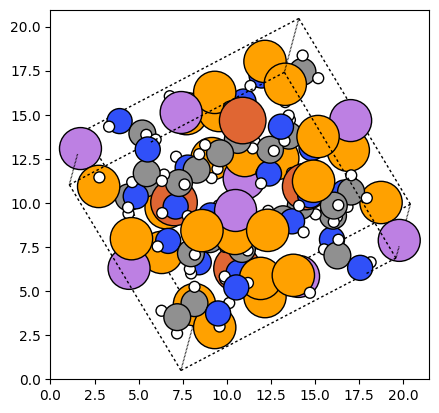

In [98]:
plot_atoms(atoms, rotation='45x,75y,75z')

In [97]:
len(pos)

90

In [96]:
for idx, (c_p, p) in enumerate(zip(pos, cell_pos_wrap)):
    if np.allclose(c_p, p, atol=1e-1, rtol=1e-1):
        pass
    else:
        print(idx, c_p, p)

0 [5.6495789, -4.8958247, 3.5803382] [-0.45592105  1.35267528  3.58033819]
1 [4.7377368, 4.8958247, 10.7410146] [5.64957895 7.60117528 3.58033819]
2 [-0.2072373, -0.3761597, 4.9644969] [-1.36776316 11.14432472 10.74101457]
3 [11.5063952, -0.3761597, 2.1961794] [ 4.73773684  4.89582472 10.74101457]
4 [10.5945531, 0.3761597, 9.3568558] [-0.20723733 12.1208403   4.96449693]
5 [-1.1190794, 0.3761597, 12.1251733] [5.89826267 5.8723403  4.96449693]
6 [0.4893104, -0.2311945, 5.5165851] [11.50639523 12.1208403   2.19617945]
7 [10.8098475, -0.2311945, 1.6440913] [5.40089523 5.8723403  2.19617945]
8 [9.8980053, 0.2311945, 8.8047677] [10.59455312  0.3761597   9.35685583]
9 [-0.4225317, 0.2311945, 12.6772615] [4.48905312 6.6246597  9.35685583]
10 [5.1568144, 5.7698649, 5.4650282] [-1.11907944  0.3761597  12.12517331]
11 [6.1423435, 5.7698649, 1.6956482] [ 4.98642056  6.6246597  12.12517331]
12 [5.2305014, -5.7698649, 8.8563245] [ 0.48931044 12.2658055   5.51658508]
13 [4.2449723, -5.7698649, 12.62

In [6]:
view = nglview.show_ase(atoms)
view.add_unitcell()
view.control.rotate([0.2, 0, 0, 1])  
view

NGLWidget()

In [114]:
ref_molecule = Atoms(symbols=ref_labels, scaled_positions=ref_fracs, cell=cell_vector, pbc=True)

<Axes: >

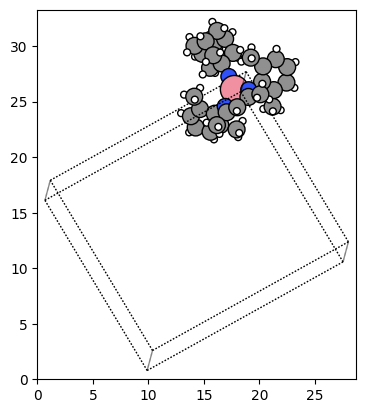

In [115]:
plot_atoms(ref_molecule, rotation='45x,75y,75z')

In [9]:
view = nglview.show_ase(ref_molecule, )
view.add_unitcell()
# view.control.rotate([0, 0, 0, 1])  
view

NGLWidget()

In [10]:
ref_molecule.get_scaled_positions()

array([[0.08075, 0.1685 , 0.21068],
       [0.92286, 0.9549 , 0.2213 ],
       [0.8965 , 0.169  , 0.3284 ],
       [0.9105 , 0.953  , 0.3654 ],
       [0.0054 , 0.841  , 0.3633 ],
       [0.8179 , 0.838  , 0.3894 ],
       [0.8307 , 0.668  , 0.4519 ],
       [0.876  , 0.664  , 0.1449 ],
       [0.7889 , 0.762  , 0.1655 ],
       [0.7749 , 0.965  , 0.1132 ],
       [0.855  , 0.982  , 0.0677 ],
       [0.9166 , 0.797  , 0.0879 ],
       [0.832  , 0.25   , 0.313  ],
       [0.957  , 0.291  , 0.354  ],
       [0.     , 0.666  , 0.375  ],
       [0.07   , 0.92   , 0.363  ],
       [0.734  , 0.896  , 0.354  ],
       [0.794  , 0.666  , 0.515  ],
       [0.88   , 0.523  , 0.442  ],
       [0.908  , 0.497  , 0.172  ],
       [0.738  , 0.697  , 0.213  ],
       [0.71   , 0.09   , 0.11   ],
       [0.868  , 0.125  , 0.021  ],
       [0.99   , 0.762  , 0.061  ]])

In [11]:
from cell2mol.classes import cell
from cell2mol.cell_operations import frac2cart_fromparam

ref_pos = frac2cart_fromparam(ref_fracs, cell_param)
refcell = cell(name, ref_labels, ref_pos, ref_fracs, cell_vector, cell_param)

In [12]:
refcell

------------- Cell2mol CELL Object ----------------
 Version               = 2.0
 Type                  = cell
 Name (Refcode)        = MALNET
 Num Atoms             = 24
 Cell Parameters a:c   = [12.756, 6.036, 13.814]
 Cell Parameters al:ga = [90.0, 106.39, 90.0]
---------------------------------------------------

In [109]:
import numpy as np

# Define the arrays
array1 = np.array([0.0, 0.10824, 0.25])
array2 = np.array([1.0, 0.10824, 0.25])

# Apply modulus operation to wrap the coordinates within [0, 1)
array1_mod = np.remainder(array1, 1)
array2_mod = np.remainder(array2, 1)

# Check if the two arrays are equivalent within the unit cell
equivalent = np.allclose(array1_mod, array2_mod)

print("Are the two arrays equivalent within the unit cell?", equivalent)


Are the two arrays equivalent within the unit cell? True


In [116]:
new_structures = apply_symmetry_operations_reference(refcell, cell_vector, sym_ops, normalize=True)

In [117]:
for new in new_structures:
    print(len(new))

45
45
45
45


<Axes: >

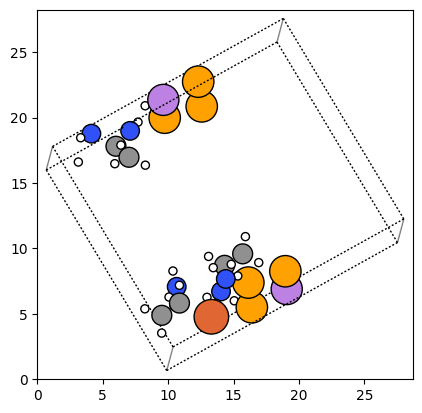

In [118]:
plot_atoms(new_structures[0], rotation='45x,75y,75z')

In [26]:
cell_pos

array([[ 0.20882649,  1.017066  ,  2.79206699],
       [ 2.27122159,  4.035066  , 10.46057678],
       [ 8.64922159,  5.018934  , 10.46057678],
       [ 6.58682649,  2.000934  ,  2.79206699],
       [10.9093854 ,  5.7637764 ,  2.93281007],
       [ 4.32666268,  2.7457764 , 10.3198337 ],
       [-2.05133732,  0.2722236 , 10.3198337 ],
       [ 4.5313854 ,  3.2902236 ,  2.93281007],
       [10.15566659,  1.020084  ,  4.35216821],
       [ 5.08038149,  4.038084  ,  8.90047555],
       [-1.29761851,  5.015916  ,  8.90047555],
       [ 3.77766659,  1.997916  ,  4.35216821],
       [10.19002637,  5.752308  ,  4.84251603],
       [ 5.04602171,  2.734308  ,  8.41012773],
       [-1.33197829,  0.283692  ,  8.41012773],
       [ 3.81202637,  3.301692  ,  4.84251603],
       [-1.34724353,  5.076276  ,  4.81468548],
       [ 3.82729161,  2.058276  ,  8.43795829],
       [10.20529161,  0.959724  ,  8.43795829],
       [ 5.03075647,  3.977724  ,  4.81468548],
       [ 8.91526992,  5.058168  ,  5.160

In [25]:
new_structures[4].positions

array([[-0.20882649, -1.017066  , -2.79206699],
       [ 1.8466146 ,  0.2722236 , -2.93281007],
       [ 2.60033341, -1.020084  , -4.35216821],
       [ 2.56597363,  0.283692  , -4.84251603],
       [ 1.34724353,  0.959724  , -4.81468548],
       [ 3.84073008,  0.977832  , -5.16057948],
       [ 3.92107527,  2.003952  , -5.98886972],
       [ 2.14655723,  2.028096  , -1.92030808],
       [ 3.33790264,  1.436568  , -2.19331254],
       [ 3.31262376,  0.21126   , -1.50019927],
       [ 2.11351135,  0.108648  , -0.89720398],
       [ 1.40648037,  1.225308  , -1.16490739],
       [ 3.36306695, -1.509     , -4.1480775 ],
       [ 1.92838298, -1.756476  , -4.69143589],
       [ 1.46173197,  2.016024  , -4.96974141],
       [ 0.52203655,  0.48288   , -4.81070969],
       [ 4.77297098,  0.627744  , -4.69143589],
       [ 4.63518124,  2.016024  , -6.82511154],
       [ 3.25361475,  2.879172  , -5.85766855],
       [ 1.84399973,  3.036108  , -2.27945473],
       [ 4.17233576,  1.828908  , -2.822

In [ ]:
2, 4 / 3, 5, / 

In [55]:
unit_cell = Atoms(cell=cell_vector, pbc=True)
view = nglview.show_ase(unit_cell + new_structures[0]  + new_structures[6] )
view.add_unitcell()
view

NGLWidget()

In [56]:
new_structures[0].get_positions()

array([[ 0.20882649,  1.017066  ,  2.79206699],
       [10.9093854 ,  5.7637764 ,  2.93281007],
       [10.15566659,  1.020084  ,  4.35216821],
       [10.19002637,  5.752308  ,  4.84251603],
       [-1.34724353,  5.076276  ,  4.81468548],
       [ 8.91526992,  5.058168  ,  5.16057948],
       [ 8.83492473,  4.032048  ,  5.98886972],
       [10.60944277,  4.007904  ,  1.92030808],
       [ 9.41809736,  4.599432  ,  2.19331254],
       [ 9.44337624,  5.82474   ,  1.50019927],
       [10.64248865,  5.927352  ,  0.89720398],
       [11.34951963,  4.810692  ,  1.16490739],
       [ 9.39293305,  1.509     ,  4.1480775 ],
       [10.82761702,  1.756476  ,  4.69143589],
       [-1.46173197,  4.019976  ,  4.96974141],
       [-0.52203655,  5.55312   ,  4.81070969],
       [ 7.98302902,  5.408256  ,  4.69143589],
       [ 8.12081876,  4.019976  ,  6.82511154],
       [ 9.50238525,  3.156828  ,  5.85766855],
       [10.91200027,  2.999892  ,  2.27945473],
       [ 8.58366424,  4.207092  ,  2.822

In [61]:
found = []
for kdx, (l, p, f) in enumerate(zip(cell_labels, cell_pos, cell_fracs)):
    for pdx, (c_l, c_p) in enumerate(zip(labels, pos)): 
        if np.allclose(p, c_p):
            print(kdx, l, p, f, c_l, c_p)
            found.append([kdx, pdx])

0 Br [0.20882649 1.017066   2.79206699] [0.08075 0.1685  0.21068] Br [0.2088265, 1.017066, 2.792067]
1 Br [ 2.27122159  4.035066   10.46057678] [0.41925 0.6685  0.78932] Br [2.2712216, 4.035066, 10.4605768]
2 Br [ 8.64922159  5.018934   10.46057678] [0.91925 0.8315  0.78932] Br [8.6492216, 5.018934, 10.4605768]
3 Br [6.58682649 2.000934   2.79206699] [0.58075 0.3315  0.21068] Br [6.5868265, 2.000934, 2.792067]
4 Co [10.9093854   5.7637764   2.93281007] [0.92286 0.9549  0.2213 ] Co [10.9093854, 5.7637764, 2.9328101]
5 Co [ 4.32666268  2.7457764  10.3198337 ] [0.57714 0.4549  0.7787 ] Co [4.3266627, 2.7457764, 10.3198337]
6 Co [-2.05133732  0.2722236  10.3198337 ] [0.07714 0.0451  0.7787 ] Co [-2.0513373, 0.2722236, 10.3198337]
7 Co [4.5313854  3.2902236  2.93281007] [0.42286 0.5451  0.2213 ] Co [4.5313854, 3.2902236, 2.9328101]
8 C [10.15566659  1.020084    4.35216821] [0.8965 0.169  0.3284] C [10.1556666, 1.020084, 4.3521682]
9 C [5.08038149 4.038084   8.90047555] [0.6035 0.669  0.6716

In [68]:
found

[[0, 0],
 [1, 1],
 [2, 3],
 [3, 2],
 [4, 4],
 [5, 5],
 [6, 7],
 [7, 6],
 [8, 8],
 [9, 9],
 [10, 11],
 [11, 10],
 [12, 12],
 [13, 13],
 [14, 15],
 [15, 14],
 [16, 16],
 [17, 17],
 [18, 19],
 [19, 18],
 [20, 20],
 [21, 21],
 [22, 23],
 [23, 22],
 [24, 24],
 [25, 25],
 [26, 27],
 [27, 26],
 [28, 28],
 [29, 29],
 [30, 31],
 [31, 30],
 [32, 32],
 [33, 33],
 [34, 35],
 [35, 34],
 [36, 36],
 [37, 37],
 [38, 39],
 [39, 38],
 [40, 40],
 [41, 41],
 [42, 43],
 [43, 42],
 [44, 44],
 [45, 45],
 [46, 47],
 [47, 46],
 [48, 48],
 [49, 49],
 [50, 51],
 [51, 50],
 [52, 52],
 [53, 53],
 [54, 55],
 [55, 54],
 [57, 57],
 [58, 59],
 [59, 58],
 [60, 60],
 [61, 61],
 [62, 63],
 [63, 62],
 [64, 64],
 [65, 65],
 [66, 67],
 [67, 66],
 [68, 68],
 [69, 69],
 [70, 71],
 [71, 70],
 [72, 72],
 [73, 73],
 [74, 75],
 [75, 74],
 [76, 76],
 [77, 77],
 [78, 79],
 [79, 78],
 [80, 80],
 [81, 81],
 [82, 83],
 [83, 82],
 [84, 84],
 [85, 85],
 [86, 87],
 [87, 86],
 [88, 88],
 [89, 89],
 [90, 91],
 [91, 90],
 [92, 92],
 [93, 93

In [69]:
[i[0] for i in found]

[0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47,
 48,
 49,
 50,
 51,
 52,
 53,
 54,
 55,
 57,
 58,
 59,
 60,
 61,
 62,
 63,
 64,
 65,
 66,
 67,
 68,
 69,
 70,
 71,
 72,
 73,
 74,
 75,
 76,
 77,
 78,
 79,
 80,
 81,
 82,
 83,
 84,
 85,
 86,
 87,
 88,
 89,
 90,
 91,
 92,
 93,
 94,
 95]

In [70]:
[ i for i in range(len(pos)) if i not in [i[0] for i in found]]

[56]

In [71]:
[ i for i in range(len(pos)) if i not in [i[1] for i in found]]

[56]

In [72]:
pos[56], cell_pos[56]

([-1.461732, 4.019976, 4.9697414],
 array([11.29426803,  4.019976  ,  4.96974141]))

In [ ]:
56 cell_labels[i]='H' cell_pos[i]=array([11.29426803,  4.019976  ,  4.96974141]) cell_fracs[i]=array([0.   , 0.666, 0.375])

In [203]:
new = new_structures[7]
new_labels =  new.get_chemical_symbols()
new_pos = new.get_positions()    
new_fracs = new.get_scaled_positions()
new_pos

array([[ 6.16917351,  4.035066  , -2.79206699],
       [-4.5313854 ,  8.7817764 , -2.93281007],
       [-3.77766659,  4.038084  , -4.35216821],
       [-3.81202637,  8.770308  , -4.84251603],
       [ 7.72524353,  8.094276  , -4.81468548],
       [-2.53726992,  8.076168  , -5.16057948],
       [-2.45692473,  7.050048  , -5.98886972],
       [-4.23144277,  7.025904  , -1.92030808],
       [-3.04009736,  7.617432  , -2.19331254],
       [-3.06537624,  8.84274   , -1.50019927],
       [-4.26448865,  8.945352  , -0.89720398],
       [-4.97151963,  7.828692  , -1.16490739],
       [-3.01493305,  4.527     , -4.1480775 ],
       [-4.44961702,  4.774476  , -4.69143589],
       [ 7.83973197,  7.037976  , -4.96974141],
       [ 6.90003655,  8.57112   , -4.81070969],
       [-1.60502902,  8.426256  , -4.69143589],
       [-1.74281876,  7.037976  , -6.82511154],
       [-3.12438525,  6.174828  , -5.85766855],
       [-4.53400027,  6.017892  , -2.27945473],
       [-2.20566424,  7.225092  , -2.822

In [176]:
sp_idx = 0
for jdx, (n_l, n_p, n_f) in enumerate(zip(new_labels, new_pos, new_fracs)):
    if jdx == 14 :
        print(f"symmtry operation {sp_idx}:", f"atom of new (index: {jdx})", n_l, n_p, n_f)
        for kdx, (l, p, f) in enumerate(zip(cell_labels, cell_pos, cell_fracs)):
            if n_l == l and np.allclose(n_p, p, atol=1e-1, rtol=1e-1):
                print(f"symmtry operation {sp_idx}:", f"atom of new (index: {jdx})", n_l, n_p, n_f, \
                      f"is the same as the atom of the unit cell (index: {kdx})", l, p, f)

symmtry operation 0: atom of new (index: 14) H [-1.46173197  4.019976    4.96974141] [0.    0.666 0.375]


In [173]:
len(cell_pos)

96

In [193]:
idx = 56
for jdx, new in enumerate(new_structures):
    new_labels =  new.get_chemical_symbols()
    new_pos = new.get_positions()    
    new_fracs = new.get_scaled_positions()
    for kdx, (l, p, f) in enumerate(zip(new_labels, new_pos, new_fracs)):
        if l == cell_labels[idx] and np.allclose(p, cell_pos[idx], atol=1e-1, rtol=1e-1) :
            print(f"symmtry operation {jdx}:", f"new symmetry atom index {kdx}", l, p, f)
            if np.allclose(f, cell_fracs[idx], atol=1e-5, rtol=1e-3):
                print(f"\tsame frac", f, cell_fracs[idx])
            else:
                print(f"\tdifferent frac", f, cell_fracs[idx])
                
    # if new_labels == cell_labels[idx] :
    #     if np.allclose(cell_pos[idx], ):

In [ ]:
ref

In [153]:
new_structures[15].get_chemical_symbols()

['Fe',
 'N',
 'C',
 'C',
 'H',
 'H',
 'H',
 'Sb',
 'F',
 'F',
 'N',
 'C',
 'C',
 'H',
 'H',
 'H',
 'N',
 'C',
 'C',
 'H',
 'H',
 'H',
 'N',
 'C',
 'C',
 'H',
 'H',
 'H',
 'N',
 'C',
 'C',
 'H',
 'H',
 'H',
 'N',
 'C',
 'C',
 'H',
 'H',
 'H',
 'F',
 'F',
 'F',
 'F']

In [151]:
t = np.array([0.6667, 0.3333, 0.3333])
type(t)

numpy.ndarray

In [65]:
target_list = [0, 1, 2, 3, 4, 5, 6, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]

sublists = [
    [0, 1, 10, 16, 22, 28, 34, 2, 11, 17, 23, 29, 35, 3, 36, 4, 37, 5, 38, 6, 39, 12, 13, 14, 15, 24, 25, 26, 27, 18, 19, 20, 21, 30, 33], 
    [0, 1, 10, 16, 22, 28, 34, 2, 11, 17, 23, 29, 35, 18, 24, 19, 25, 20, 26, 21, 27, 36, 37, 38, 39, 3, 4, 5, 6, 12, 13, 14, 15, 30, 32, 33], 
    [10, 11, 12, 13, 14, 15, 0, 22, 23, 24, 26, 28, 29, 30, 31, 32, 33, 1, 2, 3, 5, 16, 17, 18, 20, 34, 35, 36, 38, 4, 25, 21, 27, 39, 19], 
]

# Convert target list to a set for efficient operations
target_set = set(target_list)

# Initialize a list to store the missing elements for each sublist
missing_elements = []

# Compute the missing elements for each sublist
for sublist in sublists:
    sublist_set = set(sublist)
    missing = target_set - sublist_set  # Elements in target_list but not in sublist
    missing_elements.append(sorted(list(missing)))  # Convert to sorted list for readability

missing_elements


[[31, 32], [31], [6, 37]]

In [ ]:
     [6], [13], [14], [13], [19]]

In [140]:
def lists_overlap(list1, list2):
    # Convert lists to sets
    set1 = set(list1)
    set2 = set(list2)
    
    # Check if the intersection of both sets is non-empty
    if set1.intersection(set2):
        return True  # There is overlap
    else:
        return False  # No overlap

# Example usage
list1 = [1, 2, 3, 4]
list2 = [3, 4, 5, 6]
list3 = [7, 8, 9]
if set(list1).intersection(set(list3)):
    print("yes")
# print(lists_overlap(list1, list2))  # This will print True, as they overlap.
# print(lists_overlap(list1, list3))  # This will print False, as they do not overlap.


In [ ]:
 [[0, 1, 10, 16, 22, 28, 34, 2, 11, 17, 23, 29, 35, 3, 36, 4, 5, 6, 18, 19, 20, 21, 12, 13, 14, 15, 24], 
  [0, 1, 10, 16, 22, 28, 34, 2, 11, 17, 23, 29, 35, 18, 24, 19, 20, 21, 3, 4, 5, 6, 36, 37, 38, 39, 12, 13, 14, 15], 
  [10, 11, 12, 13, 14, 15, 0, 1, 2, 3, 5, 16, 17, 18, 20, 28, 29, 30, 34, 35, 36, 4, 19, 21], 
  [25], [6], [27], [32], [12, 13, 14, 15], [6], [5], [4], [12, 13, 14, 15], 
  [21], [6], [20], [5], [19], [4], [1, 2, 3, 5], [21], [15], [14], [19], [13]]

In [71]:
rem_frag_list = np.load("/Users/ycho/cell2mol/cell2mol/test/ACEYOW/rem_frag_list.pkl",allow_pickle=True)

<AxesSubplot: >

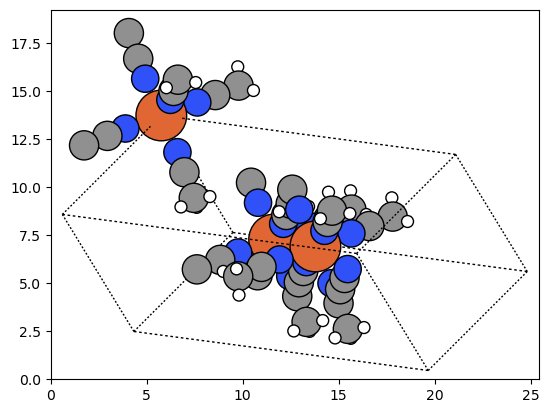

In [82]:
combined_mol = Atoms(symbols=rem_frag_list[0].labels, positions=rem_frag_list[0].coord, cell=cell_vector, pbc=True) + \
Atoms(symbols=rem_frag_list[1].labels, positions=rem_frag_list[1].coord, cell=cell_vector, pbc=True) + \
Atoms(symbols=rem_frag_list[2].labels, positions=rem_frag_list[2].coord, cell=cell_vector, pbc=True) + \
Atoms(symbols=rem_frag_list[3].labels, positions=rem_frag_list[3].coord, cell=cell_vector, pbc=True) 
plot_atoms(combined_mol, rotation='45x,50y,45z')

<AxesSubplot: >

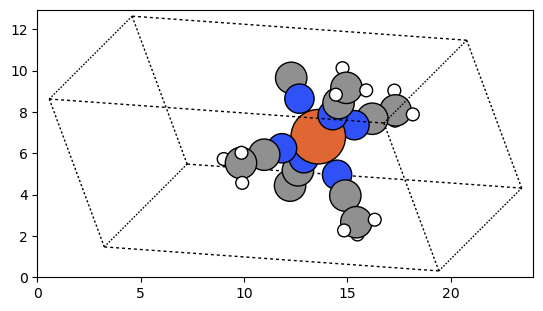

In [54]:
mol = rem_frag_list[0]
# ref_molecule = Atoms(symbols=mol.labels, scaled_positions=mol.frac_coord, cell=cell_vector, pbc=True)
ref_molecule = Atoms(symbols=rem_frag_list[0].labels, scaled_positions=rem_frag_list[0].frac_coord, cell=cell_vector, pbc=True)
print()
plot_atoms(ref_molecule, rotation='45x,60y,45z')

<AxesSubplot: >

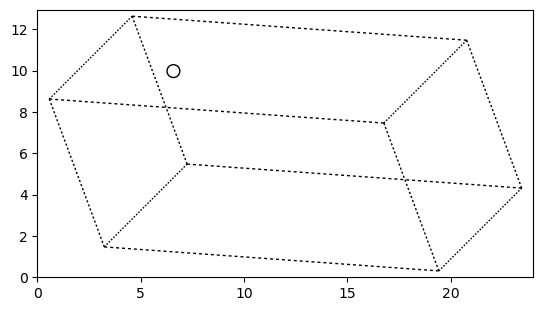

In [64]:
mol = rem_frag_list[14]
# print(mol.frac_coord)
ref_molecule = Atoms(symbols=mol.labels, scaled_positions=mol.frac_coord, cell=cell_vector, pbc=True)
# ref_molecule = Atoms(symbols=mol.labels, positions=mol.coord, cell=cell_vector, pbc=True)

plot_atoms(ref_molecule, rotation='45x,60y,45z')

ValueError: zero-size array to reduction operation minimum which has no identity

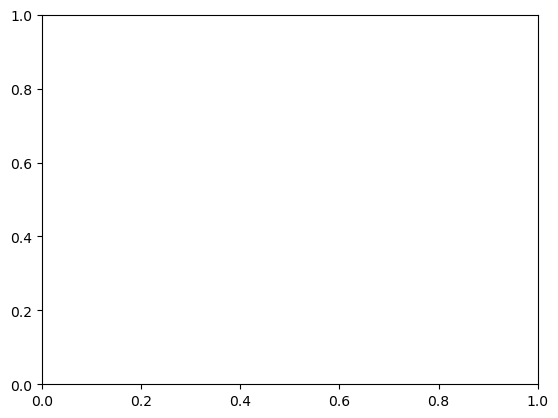

In [69]:
combine = Atoms(cell=cell_vector, pbc=True)
plot_atoms(combine)

In [ ]:

for mol in rem_frag_list:
    ref_molecule = Atoms(symbols=mol.labels, scaled_positions=mol.frac_coord, cell=cell_vector, pbc=True)
    plot_atoms(ref_molecule, rotation='45x,60y,45z')
combined_mol = 

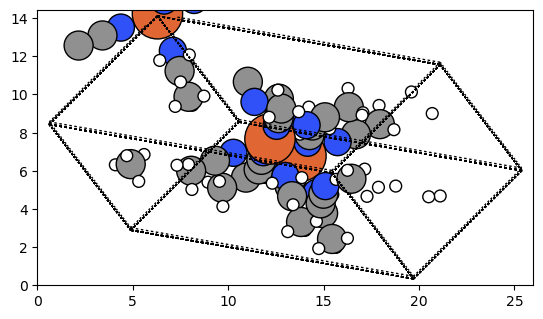

In [65]:
for mol in rem_frag_list:
    # ref_molecule = Atoms(symbols=mol.labels, scaled_positions=mol.frac_coord, cell=cell_vector, pbc=True)
    ref_molecule = Atoms(symbols=mol.labels, positions=mol.coord, cell=cell_vector, pbc=True)

    plot_atoms(ref_molecule, rotation='45x,45y,45z')

In [ ]:
[0, 1, 2, 3, 4, 5, 6, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]

{0, 1, 2, 3, 4, 5, 6, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 28, 29, 34, 35, 36, 37, 38, 39}

In [24]:
len({0, 1, 2, 3, 4, 5, 6, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 28, 29, 34, 35, 36, 37, 38, 39})

30

In [23]:
from itertools import combinations

def merge_elements(fragments):
    # Start an infinite loop to handle dynamic list updates
    while True:
        # Create an index list for the current state of fragments
        idx_list = list(range(len(fragments)))
        # Keep track of whether any items were merged during this pass
        merged = False

        # Generate all possible combinations of indices for current fragments
        for comb, idx_comb in zip(combinations(fragments, 2), combinations(idx_list, 2)):
            print(comb, idx_comb)  # Optional: for debugging to see the pairs being processed

            # Check if these indices should be merged (e.g., based on some condition)
            if should_merge(comb, idx_comb):  # Define your merge condition here
                print('merged:', comb, 'at indices', idx_comb)
                # Merge fragments and update the first element in place
                fragments[idx_comb[0]] = comb[0] + '-' + comb[1]
                # Remove the second element from the list
                fragments.pop(idx_comb[1])
                # Set merged flag to True as we made a change
                merged = True
                # Break out of the for-loop to reset combinations
                break

        # If no items were merged in this pass, stop the while loop
        if not merged:
            break

    return fragments

def should_merge(comb, idx_comb):
    # Example merge condition: based on specific index pairs or content
    return idx_comb == (0, 4) or idx_comb == (1,2) # Customize this condition based on your needs

# Example usage
remaining_frag = ['H3-C2-N', 'H-C2-N', 'C2-F', 'C2-N', 'H', 'Fe', 'H']
result = merge_elements(remaining_frag)
print('Final fragments:', result)


('H3-C2-N', 'H-C2-N') (0, 1)
('H3-C2-N', 'C2-F') (0, 2)
('H3-C2-N', 'C2-N') (0, 3)
('H3-C2-N', 'H') (0, 4)
merged: ('H3-C2-N', 'H') at indices (0, 4)
('H3-C2-N-H', 'H-C2-N') (0, 1)
('H3-C2-N-H', 'C2-F') (0, 2)
('H3-C2-N-H', 'C2-N') (0, 3)
('H3-C2-N-H', 'Fe') (0, 4)
merged: ('H3-C2-N-H', 'Fe') at indices (0, 4)
('H3-C2-N-H-Fe', 'H-C2-N') (0, 1)
('H3-C2-N-H-Fe', 'C2-F') (0, 2)
('H3-C2-N-H-Fe', 'C2-N') (0, 3)
('H3-C2-N-H-Fe', 'H') (0, 4)
merged: ('H3-C2-N-H-Fe', 'H') at indices (0, 4)
('H3-C2-N-H-Fe-H', 'H-C2-N') (0, 1)
('H3-C2-N-H-Fe-H', 'C2-F') (0, 2)
('H3-C2-N-H-Fe-H', 'C2-N') (0, 3)
('H-C2-N', 'C2-F') (1, 2)
merged: ('H-C2-N', 'C2-F') at indices (1, 2)
('H3-C2-N-H-Fe-H', 'H-C2-N-C2-F') (0, 1)
('H3-C2-N-H-Fe-H', 'C2-N') (0, 2)
('H-C2-N-C2-F', 'C2-N') (1, 2)
merged: ('H-C2-N-C2-F', 'C2-N') at indices (1, 2)
('H3-C2-N-H-Fe-H', 'H-C2-N-C2-F-C2-N') (0, 1)
Final fragments: ['H3-C2-N-H-Fe-H', 'H-C2-N-C2-F-C2-N']


In [21]:
from itertools import combinations
remaining_frag = ['H3-C2-N', 'H-C2-N', 'C2-F', 'C2-N', 'H', 'Fe', 'H']
idx_list = range(len(remaining_frag))
for comb, idx_comb in zip(combinations(remaining_frag, 2), combinations(idx_list, 2)):
    print(comb, idx_comb)
    if idx_comb == (0, 4):
        print('merged')
        remaining_frag[idx_comb[0]] = comb[0] + comb[1]
        remaining_frag.pop(idx_comb[1])
        print(remaining_frag)
        idx_list = range(len(remaining_frag))
        print(idx_list)

('H3-C2-N', 'H-C2-N') (0, 1)
('H3-C2-N', 'C2-F') (0, 2)
('H3-C2-N', 'C2-N') (0, 3)
('H3-C2-N', 'H') (0, 4)
merged
['H3-C2-NH', 'H-C2-N', 'C2-F', 'C2-N', 'Fe', 'H']
range(0, 6)
('H3-C2-N', 'Fe') (0, 5)
('H3-C2-N', 'H') (0, 6)
('H-C2-N', 'C2-F') (1, 2)
('H-C2-N', 'C2-N') (1, 3)
('H-C2-N', 'H') (1, 4)
('H-C2-N', 'Fe') (1, 5)
('H-C2-N', 'H') (1, 6)
('C2-F', 'C2-N') (2, 3)
('C2-F', 'H') (2, 4)
('C2-F', 'Fe') (2, 5)
('C2-F', 'H') (2, 6)
('C2-N', 'H') (3, 4)
('C2-N', 'Fe') (3, 5)
('C2-N', 'H') (3, 6)
('H', 'Fe') (4, 5)
('H', 'H') (4, 6)
('Fe', 'H') (5, 6)


<AxesSubplot: >

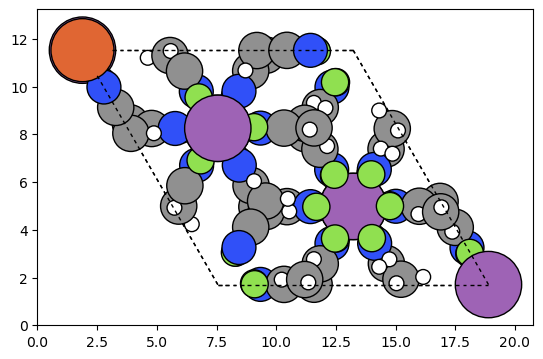

In [5]:
plot_atoms(atoms)

In [6]:
temp = [[0, 1, 10, 16, 22, 28, 34, 2, 11, 17, 23, 29, 35, 3, 12, 18, 24, 36, 4, 13, 19, 5, 14, 20, 6, 15, 21, 7, 8, 40, 41, 9, 42, 43],
[0, 1, 10, 16, 22, 28, 34, 2, 11, 17, 23, 29, 35, 3, 12, 18, 24, 36, 4, 13, 19, 37, 5, 14, 20, 38, 6, 15, 21, 39, 7, 8, 40, 41, 9, 42, 43],
[0, 1, 10, 16, 28, 34, 2, 11, 17, 29, 35, 3, 12, 18, 30, 36, 4, 13, 19, 25, 5, 14, 20, 6, 15, 21, 27, 7, 8, 40, 41, 9, 42, 43],
[32],
[12, 4, 13, 5, 14, 6, 15, 7, 8, 40, 41, 9, 42, 43],
[12, 4, 13, 19, 5, 14, 20, 6, 15, 21, 7, 8, 40, 41, 9, 42, 43],
[1, 2, 3, 13, 19, 5, 14, 15, 21, 7, 8, 40, 41, 9, 42, 43]]

In [7]:
from collections import Counter
element_counts = Counter(cell_labels)
element_counts

Counter({'Fe': 3, 'N': 18, 'C': 36, 'H': 54, 'Sb': 6, 'F': 36})

In [13]:
for i, l in enumerate(ref_labels) :
    if not np.allclose(ref_fracs[i], new_structures[0].get_scaled_positions()[i]):
        print(i, l, ref_fracs[i], new_structures[0].get_scaled_positions()[i])

12 C [0.3119, -0.023, 0.4763] [0.3119 0.977  0.4763]
13 H [0.324, -0.0037, 0.5316] [0.324  0.9963 0.5316]
14 H [0.3122, -0.1078, 0.4657] [0.3122 0.8922 0.4657]
15 H [0.2249, -0.0326, 0.4597] [0.2249 0.9674 0.4597]
18 C [1.023, 0.3349, 0.4763] [0.023  0.3349 0.4763]
19 H [1.0037, 0.3277, 0.5316] [0.0037 0.3277 0.5316]
20 H [1.1078, 0.42, 0.4657] [0.1078 0.42   0.4657]
21 H [1.0326, 0.2575, 0.4597] [0.0326 0.2575 0.4597]
24 C [0.668233, -0.021433, 0.190367] [0.668233 0.978567 0.190367]
25 H [0.66103, -0.00933, 0.13507] [0.66103 0.99067 0.13507]
26 H [0.75333, -0.02113, 0.20097] [0.75333 0.97887 0.20097]
27 H [0.59083, -0.10843, 0.20697] [0.59083 0.89157 0.20697]
30 C [1.021433, 0.689667, 0.190367] [0.021433 0.689667 0.190367]
31 H [1.00933, 0.67037, 0.13507] [0.00933 0.67037 0.13507]
32 H [1.02113, 0.77447, 0.20097] [0.02113 0.77447 0.20097]
33 H [1.10843, 0.69927, 0.20697] [0.10843 0.69927 0.20697]


<AxesSubplot: >

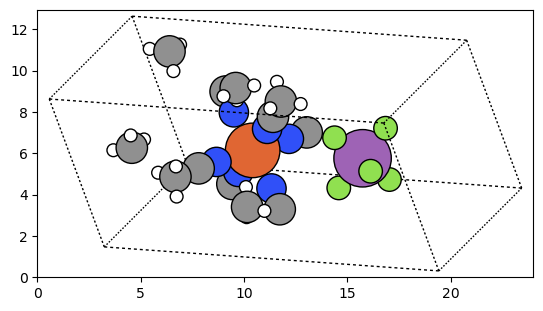

In [18]:
plot_atoms(new_structures[1], rotation='45x,60y,45z')

In [ ]:
[0.02143333, 0.68966667, 0.19036667]

In [39]:
new_labels[12]

'C'

In [43]:
for idx, row in enumerate(cell_pos):
    if np.allclose(row, np.array([-3.66729132,  6.77290934,  3.30446075])):
        print(idx, cell_labels[idx], row, cell_fracs[idx])

52 C [-3.66729132  6.77290934  3.30446075] [0.02143333 0.68966667 0.19036667]


In [58]:
cell_fracs

array([[6.66700000e-01, 3.33300000e-01, 3.33300000e-01],
       [3.33366667e-01, 6.66633333e-01, 6.66633333e-01],
       [3.33333333e-05, 9.99966667e-01, 9.99966667e-01],
       [6.65900000e-01, 4.90600000e-01, 4.02530000e-01],
       [5.09400000e-01, 1.75300000e-01, 4.02530000e-01],
       [8.24700000e-01, 3.34100000e-01, 4.02530000e-01],
       [3.32566667e-01, 8.23933333e-01, 7.35863333e-01],
       [1.76066667e-01, 5.08633333e-01, 7.35863333e-01],
       [4.91366667e-01, 6.67433333e-01, 7.35863333e-01],
       [9.99233333e-01, 1.57266667e-01, 6.91966667e-02],
       [8.42733333e-01, 8.41966667e-01, 6.91966667e-02],
       [1.58033333e-01, 7.66666667e-04, 6.91966667e-02],
       [3.34100000e-01, 5.09400000e-01, 5.97470000e-01],
       [4.90600000e-01, 8.24700000e-01, 5.97470000e-01],
       [1.75300000e-01, 6.65900000e-01, 5.97470000e-01],
       [6.67433333e-01, 1.76066667e-01, 2.64136667e-01],
       [8.23933333e-01, 4.91366667e-01, 2.64136667e-01],
       [5.08633333e-01, 3.32566

In [74]:
labels[56] , cell_labels[56]

('H', 'H')

In [ ]:
a

In [75]:
for jdx, new in enumerate(new_structures):
    new_labels =  new.get_chemical_symbols()
    new_pos = new.get_positions()    
    new_fracs = new.get_scaled_positions()
    for kdx, (l, p, f) in enumerate(zip(new_labels, new_pos, new_fracs)):
        if l == 'H' and np.allclose(p, np.array([-1.461732, 4.019976, 4.9697414])) :
            print(f"symmtry operation {jdx}:", f"new symmetry atom index {kdx}", l, p, f)

symmtry operation 0: new symmetry atom index 14 H [-1.46173197  4.019976    4.96974141] [-1.74070716e-17  6.66000000e-01  3.75000000e-01]
symmtry operation 6: new symmetry atom index 14 H [-1.46173197  4.019976    4.96974141] [-1.74070716e-17  6.66000000e-01  3.75000000e-01]


In [ ]:
[-1.461732, 4.019976, 4.9697414]

In [63]:
idx = 88
for jdx, new in enumerate(new_structures):
    new_labels =  new.get_chemical_symbols()
    new_pos = new.get_positions()    
    new_fracs = new.get_scaled_positions()
    for kdx, (l, p, f) in enumerate(zip(new_labels, new_pos, new_fracs)):
        if l == cell_labels[idx] and np.allclose(p, cell_pos[idx]) :
            print(f"symmtry operation {jdx}:", f"new symmetry atom index {kdx}", l, p, f)
            if np.allclose(f, cell_fracs[idx], atol=1e-4, rtol=1e-4):
                print(f"\tsame frac", f, cell_fracs[idx])
            else:
                print(f"\tdifferent frac", f, cell_fracs[idx])
                
    # if new_labels == cell_labels[idx] :
    #     if np.allclose(cell_pos[idx], ):

symmtry operation 14: new symmetry atom index 20 H [-4.15150078  7.6056924   3.48845979] [0.02113333 0.77446667 0.20096667]
	same frac [0.02113333 0.77446667 0.20096667] [0.02113333 0.77446667 0.20096667]
symmtry operation 23: new symmetry atom index 20 H [-4.15150078  7.6056924   3.48845979] [0.02113333 0.77446667 0.20096667]
	same frac [0.02113333 0.77446667 0.20096667] [0.02113333 0.77446667 0.20096667]


In [38]:
sites,kinds = space_group.equivalent_sites([[0.02143333, 0.68966667, 0.19036667]])
new = new_structures[12]
new_fracs = new.get_scaled_positions()
new_labels =  new.get_chemical_symbols()
new_pos = new.get_positions()
idx = 12
print(new_labels[idx], new_pos[idx], new_fracs[12])
for i in sites:
    for idx, j in enumerate(new_fracs):
        if np.allclose(i, j):
            print(new_labels[idx], new_pos[idx], i, j)

C [ 2.00260868 -3.04764553  3.30446075] [ 0.02143333 -0.31033333  0.19036667]
C [1.63803411 3.25813276 3.30446075] [0.31033333 0.33176666 0.19036667] [0.31033333 0.33176667 0.19036667]


In [ ]:
[-3.66729132,  6.77290934,  3.30446075]

In [29]:
new = new_structures[0]
total = {'Fe': 0, 'N': 0, 'C': 0, 'H': 0, 'Sb': 0, 'F': 0}
for i, l in enumerate(ref_labels) :
    count = 0
    for t in temp:
        if i in t:
            count += 1
    if l == "Sb" or l == "F":
        if count != 6:
            print("error", i, l,  count, ref_fracs[i], new.get_scaled_positions()[i])
    else:    
        if count < 3:
            print("error", i, l,  count, ref_fracs[i], new.get_scaled_positions()[i])
            # if l == "N":
            #     print("error", i, l,  count, ref_fracs[i], new.get_scaled_positions()[i])
            #     for index, row in enumerate(cell_fracs):
            #         # if np.allclose(row, ref_fracs[i]):
            #         #     print(index, cell_fracs[index], cell_pos[index])

            #         if np.allclose(row, new.get_scaled_positions()[i]):
            #             print(index, cell_fracs[index], i, new.get_scaled_positions()[i])
                
    total[l] += count
total

error 22 N 2 [0.667433, 0.176067, 0.264137] [0.667433 0.176067 0.264137]
error 23 C 2 [0.667533, 0.089267, 0.232297] [0.667533 0.089267 0.232297]
error 24 C 2 [0.668233, -0.021433, 0.190367] [0.668233 0.978567 0.190367]
error 25 H 1 [0.66103, -0.00933, 0.13507] [0.66103 0.99067 0.13507]
error 26 H 0 [0.75333, -0.02113, 0.20097] [0.75333 0.97887 0.20097]
error 27 H 1 [0.59083, -0.10843, 0.20697] [0.59083 0.89157 0.20697]
error 30 C 1 [1.021433, 0.689667, 0.190367] [0.021433 0.689667 0.190367]
error 31 H 0 [1.00933, 0.67037, 0.13507] [0.00933 0.67037 0.13507]
error 32 H 1 [1.02113, 0.77447, 0.20097] [0.02113 0.77447 0.20097]
error 33 H 0 [1.10843, 0.69927, 0.20697] [0.10843 0.69927 0.20697]
error 37 H 1 [0.32963, 0.33897, 0.13507] [0.32963 0.33897 0.13507]
error 38 H 1 [0.22553, 0.24667, 0.20097] [0.22553 0.24667 0.20097]
error 39 H 1 [0.30073, 0.40917, 0.20697] [0.30073 0.40917 0.20697]


{'Fe': 3, 'N': 18, 'C': 36, 'H': 54, 'Sb': 6, 'F': 36}

In [ ]:
error 1 N 4 [0.6659, 0.4906, 0.40253] [0.6659  0.4906  0.40253]
error 2 C 4 [0.6658, 0.5774, 0.43437] [0.6658  0.5774  0.43437]
error 3 C 4 [0.6651, 0.6881, 0.4763] [0.6651 0.6881 0.4763]
error 4 H 5 [0.6723, 0.676, 0.5316] [0.6723 0.676  0.5316]
error 5 H 6 [0.58, 0.6878, 0.4657] [0.58   0.6878 0.4657]
error 6 H 5 [0.7425, 0.7751, 0.4597] [0.7425 0.7751 0.4597]
error 12 C 5 [0.3119, -0.023, 0.4763] [0.3119 0.977  0.4763]
error 13 H 6 [0.324, -0.0037, 0.5316] [0.324  0.9963 0.5316]
error 14 H 6 [0.3122, -0.1078, 0.4657] [0.3122 0.8922 0.4657]
error 15 H 6 [0.2249, -0.0326, 0.4597] [0.2249 0.9674 0.4597]
error 19 H 5 [1.0037, 0.3277, 0.5316] [0.0037 0.3277 0.5316]
error 20 H 4 [1.1078, 0.42, 0.4657] [0.1078 0.42   0.4657]
error 21 H 5 [1.0326, 0.2575, 0.4597] [0.0326 0.2575 0.4597]

In [195]:
sites,kinds = space_group.equivalent_sites([[0.6658,  0.5774,  0.43437]])
sites,kinds 

(array([[6.65800000e-01, 5.77400000e-01, 4.34370000e-01],
        [4.22600000e-01, 8.84000000e-02, 4.34370000e-01],
        [9.11600000e-01, 3.34200000e-01, 4.34370000e-01],
        [3.32466667e-01, 9.10733333e-01, 7.67703333e-01],
        [8.92666667e-02, 4.21733333e-01, 7.67703333e-01],
        [5.78266667e-01, 6.67533333e-01, 7.67703333e-01],
        [9.99133333e-01, 2.44066667e-01, 1.01036667e-01],
        [7.55933333e-01, 7.55066667e-01, 1.01036667e-01],
        [2.44933333e-01, 8.66666667e-04, 1.01036667e-01],
        [3.34200000e-01, 4.22600000e-01, 5.65630000e-01],
        [5.77400000e-01, 9.11600000e-01, 5.65630000e-01],
        [8.84000000e-02, 6.65800000e-01, 5.65630000e-01],
        [6.67533333e-01, 8.92666667e-02, 2.32296667e-01],
        [9.10733333e-01, 5.78266667e-01, 2.32296667e-01],
        [4.21733333e-01, 3.32466667e-01, 2.32296667e-01],
        [8.66666667e-04, 7.55933333e-01, 8.98963333e-01],
        [2.44066667e-01, 2.44933333e-01, 8.98963333e-01],
        [7.550

In [153]:
sites,kinds = space_group.equivalent_sites([(0.9116 , 0.3342 , 0.43437)])
sites,kinds 

(array([[9.11600000e-01, 3.34200000e-01, 4.34370000e-01],
        [6.65800000e-01, 5.77400000e-01, 4.34370000e-01],
        [4.22600000e-01, 8.84000000e-02, 4.34370000e-01],
        [5.78266667e-01, 6.67533333e-01, 7.67703333e-01],
        [3.32466667e-01, 9.10733333e-01, 7.67703333e-01],
        [8.92666667e-02, 4.21733333e-01, 7.67703333e-01],
        [2.44933333e-01, 8.66666667e-04, 1.01036667e-01],
        [9.99133333e-01, 2.44066667e-01, 1.01036667e-01],
        [7.55933333e-01, 7.55066667e-01, 1.01036667e-01],
        [8.84000000e-02, 6.65800000e-01, 5.65630000e-01],
        [3.34200000e-01, 4.22600000e-01, 5.65630000e-01],
        [5.77400000e-01, 9.11600000e-01, 5.65630000e-01],
        [4.21733333e-01, 3.32466667e-01, 2.32296667e-01],
        [6.67533333e-01, 8.92666667e-02, 2.32296667e-01],
        [9.10733333e-01, 5.78266667e-01, 2.32296667e-01],
        [7.55066667e-01, 9.99133333e-01, 8.98963333e-01],
        [8.66666667e-04, 7.55933333e-01, 8.98963333e-01],
        [2.440

In [10]:
ref_molecule = Atoms(symbols=ref_labels, scaled_positions=ref_fracs, cell=cell_vector, pbc=True)

<AxesSubplot: >

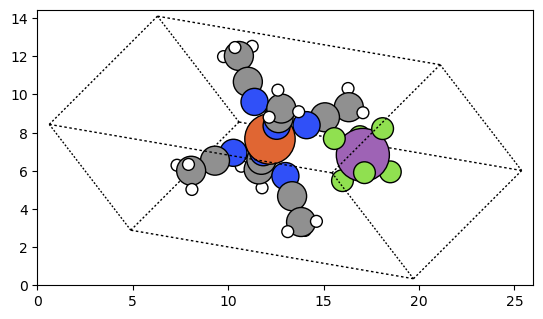

In [11]:
plot_atoms(ref_molecule,  rotation='45x,45y,45z')

In [26]:
atoms.get_scaled_positions()

array([[6.66700000e-01, 3.33300000e-01, 3.33300000e-01],
       [3.33366667e-01, 6.66633333e-01, 6.66633333e-01],
       [3.33333333e-05, 9.99966667e-01, 9.99966667e-01],
       [6.65900000e-01, 4.90600000e-01, 4.02530000e-01],
       [5.09400000e-01, 1.75300000e-01, 4.02530000e-01],
       [8.24700000e-01, 3.34100000e-01, 4.02530000e-01],
       [3.32566667e-01, 8.23933333e-01, 7.35863333e-01],
       [1.76066667e-01, 5.08633333e-01, 7.35863333e-01],
       [4.91366667e-01, 6.67433333e-01, 7.35863333e-01],
       [9.99233333e-01, 1.57266667e-01, 6.91966667e-02],
       [8.42733333e-01, 8.41966667e-01, 6.91966667e-02],
       [1.58033333e-01, 7.66666667e-04, 6.91966667e-02],
       [3.34100000e-01, 5.09400000e-01, 5.97470000e-01],
       [4.90600000e-01, 8.24700000e-01, 5.97470000e-01],
       [1.75300000e-01, 6.65900000e-01, 5.97470000e-01],
       [6.67433333e-01, 1.76066667e-01, 2.64136667e-01],
       [8.23933333e-01, 4.91366667e-01, 2.64136667e-01],
       [5.08633333e-01, 3.32566

In [24]:
for i, j in zip(ref_fracs, ref_molecule.get_scaled_positions()):
    print(i, j)

[0.6667, 0.3333, 0.3333] [0.6667 0.3333 0.3333]
[0.6659, 0.4906, 0.40253] [0.6659  0.4906  0.40253]
[0.6658, 0.5774, 0.43437] [0.6658  0.5774  0.43437]
[0.6651, 0.6881, 0.4763] [0.6651 0.6881 0.4763]
[0.6723, 0.676, 0.5316] [0.6723 0.676  0.5316]
[0.58, 0.6878, 0.4657] [0.58   0.6878 0.4657]
[0.7425, 0.7751, 0.4597] [0.7425 0.7751 0.4597]
[0.6667, 0.3333, 0.661838] [0.6667   0.3333   0.661838]
[0.6682, 0.1981, 0.7195] [0.6682 0.1981 0.7195]
[0.535, 0.1968, 0.60083] [0.535   0.1968  0.60083]
[0.5094, 0.1753, 0.40253] [0.5094  0.1753  0.40253]
[0.4226, 0.0884, 0.43437] [0.4226  0.0884  0.43437]
[0.3119, -0.023, 0.4763] [0.3119 0.977  0.4763]
[0.324, -0.0037, 0.5316] [0.324  0.9963 0.5316]
[0.3122, -0.1078, 0.4657] [0.3122 0.8922 0.4657]
[0.2249, -0.0326, 0.4597] [0.2249 0.9674 0.4597]
[0.8247, 0.3341, 0.40253] [0.8247  0.3341  0.40253]
[0.9116, 0.3342, 0.43437] [0.9116  0.3342  0.43437]
[1.023, 0.3349, 0.4763] [0.023  0.3349 0.4763]
[1.0037, 0.3277, 0.5316] [0.0037 0.3277 0.5316]
[1.1078

In [20]:
new_structures = apply_symmetry_operations_reference(ref_molecule, cell_vector, sym_ops, False)

<AxesSubplot: >

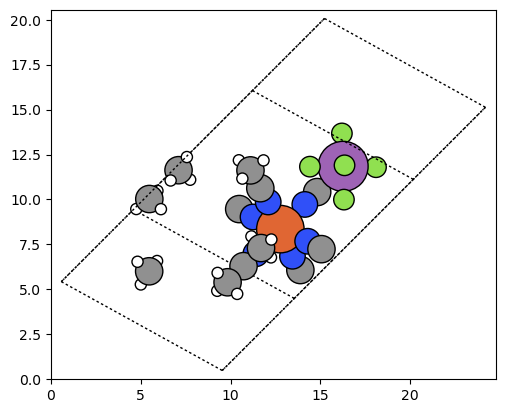

In [27]:
plot_atoms(new_structures[0], rotation='0x,60y,45z')

In [147]:
len(new_structures)

36

In [151]:
new_structures[0].get_scaled_positions()[17]

array([0.9116 , 0.3342 , 0.43437])

In [114]:
atoms.positions

array([[ 5.67046699e+00,  3.27319094e+00,  5.78555472e+00],
       [ 5.66990000e-04,  6.54670923e+00,  1.15716881e+01],
       [-5.66933301e+00,  9.82022752e+00,  1.73578214e+01],
       [ 4.76951988e+00,  4.81796422e+00,  6.98727675e+00],
       [ 4.78256065e+00,  1.72154327e+00,  6.98727675e+00],
       [ 7.45761947e+00,  3.28104738e+00,  6.98727675e+00],
       [-9.00380120e-01,  8.09148251e+00,  1.27734101e+01],
       [-8.87339350e-01,  4.99506156e+00,  1.27734101e+01],
       [ 1.78771947e+00,  6.55456567e+00,  1.27734101e+01],
       [ 1.04394199e+01,  1.54444593e+00,  1.20114342e+00],
       [ 4.78256065e+00,  8.26857985e+00,  1.20114342e+00],
       [ 1.78771947e+00,  7.52909207e-03,  1.20114342e+00],
       [ 9.00380120e-01,  5.00259065e+00,  1.03711232e+01],
       [ 8.87339350e-01,  8.09901160e+00,  1.03711232e+01],
       [-1.78771947e+00,  6.53950749e+00,  1.03711232e+01],
       [ 6.57028012e+00,  1.72907236e+00,  4.58498991e+00],
       [ 6.55723935e+00,  4.82549331e+00

In [117]:
[len(new.numbers) for new in new_structures]

[44,
 44,
 44,
 44,
 44,
 44,
 44,
 44,
 44,
 44,
 44,
 44,
 44,
 44,
 44,
 44,
 44,
 44,
 44,
 44,
 44,
 44,
 44,
 44,
 44,
 44,
 44,
 44,
 44,
 44,
 44,
 44,
 44,
 44,
 44,
 44]

<AxesSubplot: >

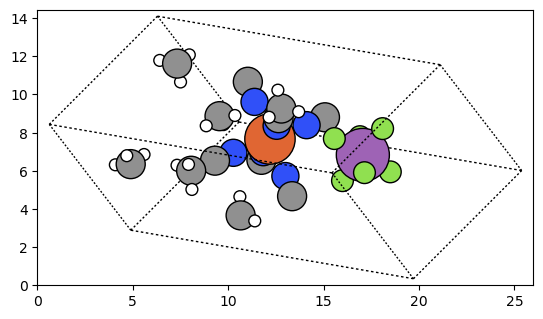

In [125]:
plot_atoms(new_structures[0], rotation='45x,45y,45z')

In [128]:
for idx, c_f in enumerate(cell_fracs):
    if np.allclose([0.9116 , 0.3342 , 0.43437], c_f):
        print(idx, c_f)

23 [0.9116  0.3342  0.43437]


In [131]:
cell_labels[52], cell_pos[52], cell_fracs[52]

('C',
 array([-3.66729132,  6.77290934,  3.30446075]),
 array([0.02143333, 0.68966667, 0.19036667]))

In [124]:
new_structures[0].numbers[17], new_structures[0].positions[17], new_structures[0].get_scaled_positions()[17]

(6,
 array([8.4424811 , 3.28202944, 7.53996821]),
 array([0.9116 , 0.3342 , 0.43437]))

In [135]:
for idx, (l, f, sf) in enumerate(zip(ref_labels, ref_fracs, new_structures[0].get_scaled_positions())):
    print(idx, l, f, sf)

0 Fe [0.6667, 0.3333, 0.3333] [0.6667 0.3333 0.3333]
1 N [0.6659, 0.4906, 0.40253] [0.6659  0.4906  0.40253]
2 C [0.6658, 0.5774, 0.43437] [0.6658  0.5774  0.43437]
3 C [0.6651, 0.6881, 0.4763] [0.6651 0.6881 0.4763]
4 H [0.6723, 0.676, 0.5316] [0.6723 0.676  0.5316]
5 H [0.58, 0.6878, 0.4657] [0.58   0.6878 0.4657]
6 H [0.7425, 0.7751, 0.4597] [0.7425 0.7751 0.4597]
7 Sb [0.6667, 0.3333, 0.661838] [0.6667   0.3333   0.661838]
8 F [0.6682, 0.1981, 0.7195] [0.6682 0.1981 0.7195]
9 F [0.535, 0.1968, 0.60083] [0.535   0.1968  0.60083]
10 N [0.5094, 0.1753, 0.40253] [0.5094  0.1753  0.40253]
11 C [0.4226, 0.0884, 0.43437] [0.4226  0.0884  0.43437]
12 C [0.3119, -0.023, 0.4763] [0.3119 0.977  0.4763]
13 H [0.324, -0.0037, 0.5316] [0.324  0.9963 0.5316]
14 H [0.3122, -0.1078, 0.4657] [0.3122 0.8922 0.4657]
15 H [0.2249, -0.0326, 0.4597] [0.2249 0.9674 0.4597]
16 N [0.8247, 0.3341, 0.40253] [0.8247  0.3341  0.40253]
17 C [0.9116, 0.3342, 0.43437] [0.9116  0.3342  0.43437]
18 C [1.023, 0.3349,

In [118]:
count = 0
for s in new_structures[0].get_scaled_positions():
    for idx, (l, f) in enumerate(zip(ref_labels, ref_fracs)):
        if np.allclose(f, s):
            print(idx, l)
            count+=1
        # else :
        #     print('not found')
print(count)

0 Fe
1 N
2 C
3 C
4 H
5 H
6 H
7 Sb
8 F
9 F
10 N
11 C
16 N
17 C
22 N
23 C
28 N
29 C
34 N
35 C
36 C
37 H
38 H
39 H
40 F
41 F
42 F
43 F
28


In [110]:
for l, f in zip(ref_labels, ref_fracs):
    print(l, f)

Fe [0.6667, 0.3333, 0.3333]
N [0.6659, 0.4906, 0.40253]
C [0.6658, 0.5774, 0.43437]
C [0.6651, 0.6881, 0.4763]
H [0.6723, 0.676, 0.5316]
H [0.58, 0.6878, 0.4657]
H [0.7425, 0.7751, 0.4597]
Sb [0.6667, 0.3333, 0.661838]
F [0.6682, 0.1981, 0.7195]
F [0.535, 0.1968, 0.60083]
N [0.5094, 0.1753, 0.40253]
C [0.4226, 0.0884, 0.43437]
C [0.3119, -0.023, 0.4763]
H [0.324, -0.0037, 0.5316]
H [0.3122, -0.1078, 0.4657]
H [0.2249, -0.0326, 0.4597]
N [0.8247, 0.3341, 0.40253]
C [0.9116, 0.3342, 0.43437]
C [1.023, 0.3349, 0.4763]
H [1.0037, 0.3277, 0.5316]
H [1.1078, 0.42, 0.4657]
H [1.0326, 0.2575, 0.4597]
N [0.667433, 0.176067, 0.264137]
C [0.667533, 0.089267, 0.232297]
C [0.668233, -0.021433, 0.190367]
H [0.66103, -0.00933, 0.13507]
H [0.75333, -0.02113, 0.20097]
H [0.59083, -0.10843, 0.20697]
N [0.823933, 0.491367, 0.264137]
C [0.910733, 0.578267, 0.232297]
C [1.021433, 0.689667, 0.190367]
H [1.00933, 0.67037, 0.13507]
H [1.02113, 0.77447, 0.20097]
H [1.10843, 0.69927, 0.20697]
N [0.508633, 0.332

<AxesSubplot: >

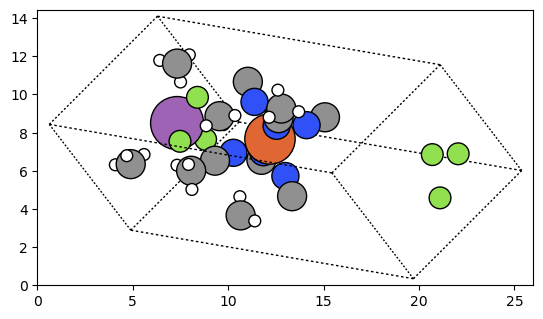

In [108]:
plot_atoms(new_structures[12],  rotation='45x,45y,45z')

<Axes: >

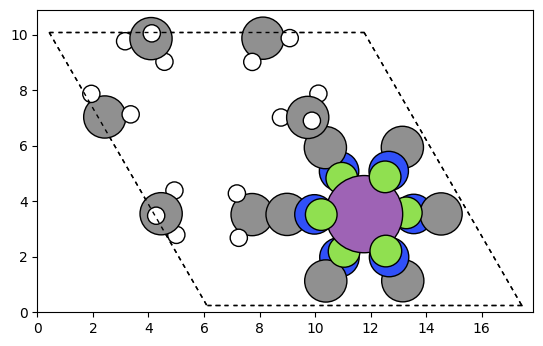

In [63]:
plot_atoms(new_structures[1])

<Axes: >

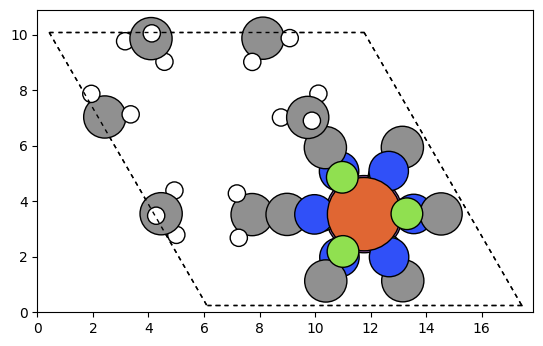

In [64]:
plot_atoms(new_structures[12])

In [21]:
for new in new_structures:
    print(len(new.numbers))

44
44
44
44
44
44
44
44
44
44
44
44
44
44
44
44
44
44
44
44
44
44
44
44
44
44
44
44
44
44
44
44
44
44
44
44


In [38]:
len([0, 3, 4, 5, 15, 16, 17, 21, 22, 23, 33, 34, 35, 39, 40, 41, 51, 52, 53, 57, 58, 59, 75, 76, 77, 93, 94, 95, 111, 117, 118, 119, 135, 136, 137])

35

In [39]:
len([0, 1, 10, 16, 22, 28, 34, 2, 11, 17, 23, 29, 35, 3, 12, 18, 24, -1, 36, 4, 13, 19, 5, 14, 20, 6, 15, 21, 7, 8, 40, 41, 9, 42, 43])

35

In [45]:
indices_in_ref=[0, 1, 10, 16, 22, 28, 34, 2, 11, 17, 23, 29, 35, 3, 12, 18, 24, -1, 36, 4, 13, 19, 5, 14, 20, 6, 15, 21, 7, 8, 40, 41, 9, 42, 43]

In [57]:
# Given lists
updated = [0, 3, 4, 5, 15, 16, 17, 21, 22, 23, 33, 34, 35, 39, 40, 41, 51, 52, 53, 57, 58, 59, 75, 76, 77, 93, 94, 95, 111, 117, 118, 119, 135, 136, 137]
indices_in_ref = [0, 1, 10, 16, 22, 28, 34, 2, 11, 17, 23, 29, 35, 3, 12, 18, 24, -1, 36, 4, 13, 19, 5, 14, 20, 6, 15, 21, 7, 8, 40, 41, 9, 42, -1]
print(len(updated), len(indices_in_ref))
# Find all indices of -1 in indices_in_ref
indices_to_remove = [i for i, x in enumerate(indices_in_ref) if x == -1]
indices_in_ref = [x for x in indices_in_ref if x != -1]

print(indices_to_remove)

# Remove corresponding elements from 'updated' starting from the highest index
for index in sorted(indices_to_remove, reverse=True):
    if index < len(updated):  # Check if index is valid for 'updated'
        updated.pop(index)

print(updated)
print(indices_in_ref)
print(len(updated), len(indices_in_ref))


35 35
[17, 34]
[0, 3, 4, 5, 15, 16, 17, 21, 22, 23, 33, 34, 35, 39, 40, 41, 51, 53, 57, 58, 59, 75, 76, 77, 93, 94, 95, 111, 117, 118, 119, 135, 136]
[0, 1, 10, 16, 22, 28, 34, 2, 11, 17, 23, 29, 35, 3, 12, 18, 24, 36, 4, 13, 19, 5, 14, 20, 6, 15, 21, 7, 8, 40, 41, 9, 42]
33 33


In [46]:
indices_in_ref.index(-1)

17

<Axes: >

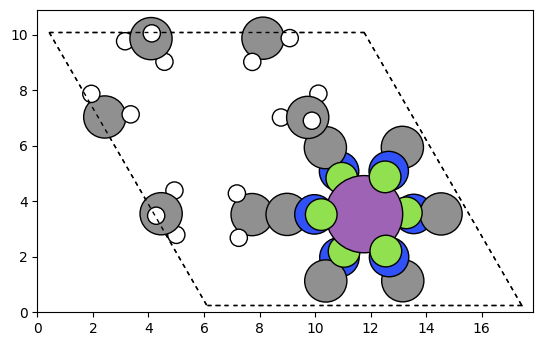

In [26]:
plot_atoms(new_structures[0])

<Axes: >

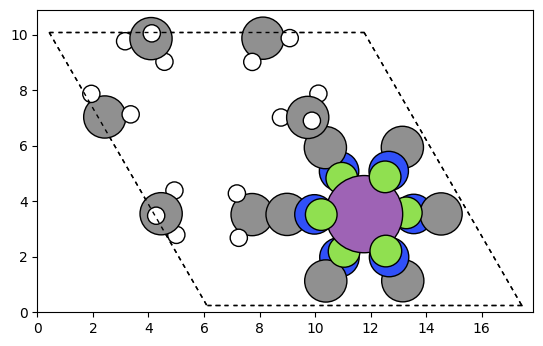

In [27]:
plot_atoms(new_structures[1])

<Axes: >

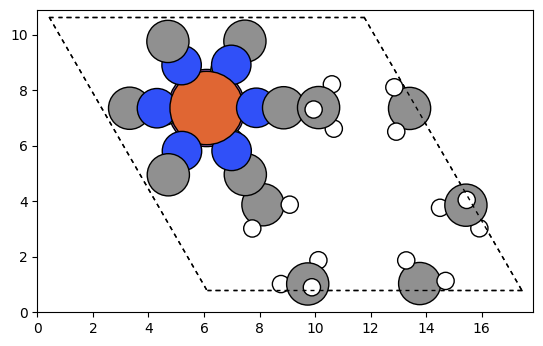

In [37]:
plot_atoms(new_structures[10])

In [9]:
from cell2mol.classes import cell
newcell = cell(name, cell_labels, cell_pos, cell_fracs, cell_vector, cell_param)
newcell.get_subtype("unit_cell")

In [10]:
newcell.get_reference_molecules(ref_labels, ref_fracs, debug=0)

#########################################
  GETREFS: Generate reference molecules  
#########################################
GETREFS: found 10 reference molecules
GETREFS: ['C6-O12-Fe', 'H24-C12-O6', 'H2-O', 'H2-O', 'H2-O', 'H24-C12-O6', 'H24-C12-O6', 'K', 'K', 'K']
GETREFS: [------------- Cell2mol MOLECULE Object --------------
 Version                      = 2.0
 Type                         = specie
 Sub-Type                     = molecule
 Number of Atoms              = 19
 Formula                      = C6-O12-Fe
 Covalent Radii Factor        = 1.3
 Metal Radii Factor           = 1.0
 Has Adjacency Matrix         = YES
 Number of Ligands            = 3
 Number of Metals             = 1
---------------------------------------------------
, ------------- Cell2mol MOLECULE Object --------------
 Version                      = 2.0
 Type                         = specie
 Sub-Type                     = molecule
 Number of Atoms              = 42
 Formula                      = H24-C12-

[------------- Cell2mol MOLECULE Object --------------
  Version                      = 2.0
  Type                         = specie
  Sub-Type                     = molecule
  Number of Atoms              = 19
  Formula                      = C6-O12-Fe
  Covalent Radii Factor        = 1.3
  Metal Radii Factor           = 1.0
  Has Adjacency Matrix         = YES
  Number of Ligands            = 3
  Number of Metals             = 1
 ---------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version                      = 2.0
  Type                         = specie
  Sub-Type                     = molecule
  Number of Atoms              = 42
  Formula                      = H24-C12-O6
  Covalent Radii Factor        = 1.3
  Metal Radii Factor           = 1.0
  Has Adjacency Matrix         = YES
 ---------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version                      = 2.0
 

In [11]:
for ref in newcell.refmoleclist:
    print(ref.formula, [(p.subtype, p.natoms) for p in ref.parents])

C6-O12-Fe [('unit_cell', 525), ('reference', 157)]
H24-C12-O6 [('unit_cell', 525), ('reference', 157)]
H2-O [('unit_cell', 525), ('reference', 157)]
H2-O [('unit_cell', 525), ('reference', 157)]
H2-O [('unit_cell', 525), ('reference', 157)]
H24-C12-O6 [('unit_cell', 525), ('reference', 157)]
H24-C12-O6 [('unit_cell', 525), ('reference', 157)]
K [('unit_cell', 525), ('reference', 157)]
K [('unit_cell', 525), ('reference', 157)]
K [('unit_cell', 525), ('reference', 157)]


In [12]:
if not newcell.has_isolated_H:  
    newcell.check_missing_H()                                     
newcell.assess_errors(ref=True)

Adjacency [8, 10, 18] ['O', 'O', 'C']
Adjacency [12, 13, 16] ['O', 'O', 'C']
Adjacency [7, 9, 17] ['O', 'O', 'C']
Adjacency [11, 14, 15] ['O', 'O', 'C']
Adjacency [1, 2, 6] ['O', 'O', 'C']
Adjacency [3, 4, 5] ['O', 'O', 'C']
Adjacency [0, 7, 8, 9] ['O', 'H', 'H', 'C']
Adjacency [1, 6, 10, 11] ['O', 'C', 'H', 'H']
Adjacency [1, 13, 14, 15] ['O', 'H', 'H', 'C']
Adjacency [2, 12, 16, 17] ['O', 'C', 'H', 'H']
Adjacency [2, 19, 20, 21] ['O', 'H', 'H', 'C']
Adjacency [3, 18, 22, 23] ['O', 'C', 'H', 'H']
Adjacency [3, 25, 26, 27] ['O', 'H', 'H', 'C']
Adjacency [4, 24, 28, 29] ['O', 'C', 'H', 'H']
Adjacency [4, 31, 32, 33] ['O', 'H', 'H', 'C']
Adjacency [5, 30, 34, 35] ['O', 'C', 'H', 'H']
Adjacency [5, 37, 38, 39] ['O', 'H', 'H', 'C']
Adjacency [0, 36, 40, 41] ['O', 'C', 'H', 'H']
Adjacency [0, 7, 8, 9] ['O', 'H', 'H', 'C']
Adjacency [1, 6, 10, 11] ['O', 'C', 'H', 'H']
Adjacency [1, 13, 14, 15] ['O', 'H', 'H', 'C']
Adjacency [2, 12, 16, 17] ['O', 'C', 'H', 'H']
Adjacency [2, 19, 20, 21] ['O',

In [13]:
from new_cell_reconstruction import *
all_molecules, reconstructed_molecules = reconstuct(ref_molecule, newcell, cell_pos, cell_fracs, cell_vector, sym_ops, debug=0)

Applying symmetry operations to reference 0
157 157
157
False
target_ref: C6-O12-Fe
Group 0: ['C3-O6-Fe', 'C-O2', 'C-O2', 'C-O2']
final_remaining ['C3-O6-Fe', 'C-O2', 'C-O2', 'C-O2'] ['fragment', 'fragment', 'fragment', 'fragment']
Fragments TO BE MERGED ['C3-O6-Fe', 'C-O2'] ['fragment', 'fragment']
Rest fragments ['C-O2', 'C-O2'] ['fragment', 'fragment']
MERGED C4-O8-Fe
small_set={1, 8, 73, 74, 9, 75, 76, 10, 11, 51, 52, 153, 154}
len(found_molecule)=0
len(bigger_fragment)=1
len(not_merged)=0
final_remaining ['C4-O8-Fe', 'C-O2', 'C-O2'] ['Rec. Fragment', 'fragment', 'fragment']
Fragments TO BE MERGED ['C4-O8-Fe', 'C-O2'] ['Rec. Fragment', 'fragment']
Rest fragments ['C-O2'] ['fragment']
MERGED C5-O10-Fe
small_set={1, 8, 73, 74, 9, 75, 76, 10, 11, 77, 80, 51, 52, 153, 154, 155}
len(found_molecule)=0
len(bigger_fragment)=1
len(not_merged)=0
final_remaining ['C5-O10-Fe', 'C-O2'] ['Rec. Fragment', 'fragment']
Fragments TO BE MERGED ['C5-O10-Fe', 'C-O2'] ['Rec. Fragment', 'fragment']
Rest 

In [17]:
len(all_molecules), len(reconstructed_molecules)

(30, 18)

In [18]:
newcell.moleclist = []
newcell.moleclist.extend(all_molecules)
newcell.moleclist.extend(reconstructed_molecules)

In [19]:
newcell

------------- Cell2mol CELL Object ----------------
 Version               = 2.0
 Type                  = cell
 Sub-Type              = unit_cell
 Name (Refcode)        = BOFFOS
 Num Atoms             = 525
 Cell Parameters a:c   = [24.369, 24.369, 9.748]
 Cell Parameters al:ga = [90.0, 90.0, 120.0]
 # Molecules:          = 48
 With Formulae:                               
    0: H2-O 
    1: H2-O 
    2: K 
    3: K 
    4: K 
    5: H2-O 
    6: H2-O 
    7: H2-O 
    8: H2-O 
    9: C6-O12-Fe 
    10: H2-O 
    11: H2-O 
    12: K 
    13: K 
    14: K 
    15: H2-O 
    16: H2-O 
    17: H2-O 
    18: H2-O 
    19: H2-O 
    20: H2-O 
    21: H2-O 
    22: K 
    23: K 
    24: K 
    25: H2-O 
    26: H2-O 
    27: H2-O 
    28: H2-O 
    29: H2-O 
    30: C6-O12-Fe 
    31: H24-C12-O6 
    32: H2-O 
    33: H24-C12-O6 
    34: H24-C12-O6 
    35: H2-O 
    36: H2-O 
    37: H24-C12-O6 
    38: H2-O 
    39: H24-C12-O6 
    40: H24-C12-O6 
    41: H2-O 
    42: C6-O12-Fe 
    43: 

In [20]:
newcell.moleclist

[------------- Cell2mol MOLECULE Object --------------
  Version                      = 2.0
  Type                         = specie
  Sub-Type                     = molecule
  Number of Atoms              = 3
  Formula                      = H2-O
  Covalent Radii Factor        = 1.3
  Metal Radii Factor           = 1.0
  Has Adjacency Matrix         = YES
  Origin                       = cell.classify_fragments
 ---------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version                      = 2.0
  Type                         = specie
  Sub-Type                     = molecule
  Number of Atoms              = 3
  Formula                      = H2-O
  Covalent Radii Factor        = 1.3
  Metal Radii Factor           = 1.0
  Has Adjacency Matrix         = YES
  Origin                       = cell.classify_fragments
 ---------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Versi

In [25]:
for specie in refcell.unique_species:
    if specie.subtype == "metal":
        print(specie.charge)
    else:
        print(specie.charge_state)    

------------- Cell2mol Charge State ---------------
 Status                          = True
 Smiles                          = O=C([O-])C(=O)[O-]
 Charge Tried                    = -2
 Uncorrected Total Charge        = -2
 Corrected Total Charge          = -2
 Corrected Absolute Total Charge = 2
 Corrected Is Zwitterion?        = False
---------------------------------------------------

3.0
------------- Cell2mol Charge State ---------------
 Status                          = True
 Smiles                          = [H]C1([H])OC([H])([H])C([H])([H])OC([H])([H])C([H])([H])OC([H])([H])C([H])([H])OC([H])([H])C([H])([H])OC([H])([H])C([H])([H])OC1([H])[H]
 Charge Tried                    = 0
 Uncorrected Total Charge        = 0
 Corrected Total Charge          = 0
 Corrected Absolute Total Charge = 0
 Corrected Is Zwitterion?        = False
---------------------------------------------------

------------- Cell2mol Charge State ---------------
 Status                          = True
 Smiles

In [ ]:
######################################################
def set_charge_state(unique_specie, target, debug: int=0):
    
    prot = unique_specie.charge_state.protonation
    final_charge = unique_specie.totcharge

    # For "reference" cell
    ref_data, target_data = arrange_data_for_reorder(unique_specie, target)
    if debug >=2 : print(ref_data, target_data)
    dummy1, dummy2, map12 = reorder(ref_data, target_data, unique_specie.coord, target.coord)
    
    if np.array_equal(map12, np.arange(len(target_data))):
        if debug >=1 : print(f"({target.subtype}) {target.formula} {final_charge=} No need to reorder")
        cs = get_charge(final_charge, prot)
        target.set_charges(cs.corr_total_charge, cs.corr_atom_charges, cs.smiles, cs.rdkit_obj)
               
    else:
        temp_prot = copy.deepcopy(prot)
        reordered_prot = temp_prot.reorder(map12)
        # print(f"{reordered_prot=}")
        # print(f"{temp_prot=}")
        # print(f"{prot=}")
        # print(map12)
        if debug >=1 : print(f"({target.subtype}) {target.formula} {final_charge=} Reordered {map12=}")
        cs = get_charge(final_charge, reordered_prot)
        target.set_charges(cs.corr_total_charge, cs.corr_atom_charges, cs.smiles, cs.rdkit_obj)

In [ ]:
# Add parent to all molecules & reconstructed molecules in unit cell 

In [30]:
for  mol in newcell.moleclist:
    print(mol.formula, [(p.subtype, p.natoms) for p in mol.parents], mol.parents_indices)

H2-O [('unit_cell', 525)] [[120, 489, 516]]
H2-O [('unit_cell', 525)] [[111, 480, 507]]
K [('unit_cell', 525)] [[1]]
K [('unit_cell', 525)] [[2]]
K [('unit_cell', 525)] [[0]]
H2-O [('unit_cell', 525)] [[121, 490, 517]]
H2-O [('unit_cell', 525)] [[112, 481, 508]]
H2-O [('unit_cell', 525)] [[122, 491, 518]]
H2-O [('unit_cell', 525)] [[113, 482, 509]]
C6-O12-Fe [('unit_cell', 525)] [[10, 69, 70, 71, 78, 79, 80, 87, 88, 89, 96, 97, 98, 456, 457, 458, 465, 466, 467]]
H2-O [('unit_cell', 525)] [[123, 492, 519]]
H2-O [('unit_cell', 525)] [[105, 474, 501]]
K [('unit_cell', 525)] [[5]]
K [('unit_cell', 525)] [[4]]
K [('unit_cell', 525)] [[3]]
H2-O [('unit_cell', 525)] [[124, 493, 520]]
H2-O [('unit_cell', 525)] [[106, 475, 502]]
H2-O [('unit_cell', 525)] [[125, 494, 521]]
H2-O [('unit_cell', 525)] [[116, 485, 512]]
H2-O [('unit_cell', 525)] [[107, 476, 503]]
H2-O [('unit_cell', 525)] [[126, 495, 522]]
H2-O [('unit_cell', 525)] [[108, 477, 504]]
K [('unit_cell', 525)] [[8]]
K [('unit_cell', 525)

In [28]:
from cell2mol.connectivity import compare_species, compare_metals
from new_charge_assignment import *
for idx, mol in enumerate(newcell.moleclist):
    print(f"Molecule {idx}: {mol.formula}")
    if mol.iscomplex:
        for jdx, lig in enumerate(mol.ligands):
            for specie in refcell.unique_species:
                if specie.subtype == "ligand":
                    issame = compare_species(lig, specie)
                    if issame:
                        # set_charge_state(specie, lig)
                        print(lig.formula, specie.formula, issame)
        for met in mol.metals:
            for specie in refcell.unique_species:
                if specie.subtype == "metal":
                    issame = compare_metals(met, specie)
                    if issame:
                        # met.set_charge(specie.charge)
                        print(met.formula, specie.formula, issame) 
    else:
        for specie in refcell.unique_species:  
            if specie.subtype == "molecule":
                issame = compare_species(mol, specie)
                if issame:
                    # set_charge_state(specie, mol)
                    print(mol.formula, specie.formula, issame)
    print("")

Molecule 0: H2-O
H2-O H2-O True

Molecule 1: H2-O
H2-O H2-O True

Molecule 2: K
K K True

Molecule 3: K
K K True

Molecule 4: K
K K True

Molecule 5: H2-O
H2-O H2-O True

Molecule 6: H2-O
H2-O H2-O True

Molecule 7: H2-O
H2-O H2-O True

Molecule 8: H2-O
H2-O H2-O True

Molecule 9: C6-O12-Fe


AttributeError: 'molecule' object has no attribute 'ligands'